# Plant Disease Classification with CNNs

This notebook trains two image classifiers on the Plant Diseases dataset:

1. A compact custom CNN baseline.
2. A MobileNetV2 transfer-learning model for the best simplicity/performance compromise.

The final section performs predictions on the standalone images in `test/test`.

## 0. Optional setup

Run this cell only if TensorFlow or scikit-learn are missing in your notebook kernel. Restart the kernel after installation if imports still fail.

In [5]:
# Optional dependency install. Run only if imports fail, then restart the kernel.
# For NVIDIA GPU runtimes, prefer the CUDA-enabled extra on Linux.
# %pip install -q 'tensorflow[and-cuda]' scikit-learn seaborn
# CPU-only fallback, if no GPU is available or needed:
# %pip install -q tensorflow scikit-learn seaborn


Note: you may need to restart the kernel to use updated packages.


## 1. Imports and configuration

In [6]:
from pathlib import Path
import ctypes
import json
import os
import random
import site

import matplotlib.pyplot as plt
import numpy as np


def preload_nvidia_libraries():
    """Load pip-installed NVIDIA CUDA libraries before TensorFlow imports.

    Some notebook kernels do not start with LD_LIBRARY_PATH pointing at the
    nvidia-* pip package libraries. TensorFlow is a CUDA build here, but it
    will skip GPU registration unless these shared libraries are discoverable.
    """
    nvidia_subdirs = [
        'cuda_runtime/lib',
        'cublas/lib',
        'cudnn/lib',
        'cufft/lib',
        'curand/lib',
        'cusolver/lib',
        'cusparse/lib',
        'nccl/lib',
        'nvjitlink/lib',
        'cuda_cupti/lib',
        'cuda_nvrtc/lib',
    ]
    candidates = []
    for site_dir in site.getsitepackages():
        nvidia_root = Path(site_dir) / 'nvidia'
        candidates.extend(nvidia_root / subdir for subdir in nvidia_subdirs)

    loaded = 0
    for lib_dir in candidates:
        if not lib_dir.exists():
            continue
        os.environ['LD_LIBRARY_PATH'] = f"{lib_dir}:{os.environ.get('LD_LIBRARY_PATH', '')}"
        for shared_library in sorted(lib_dir.glob('*.so*')):
            try:
                ctypes.CDLL(str(shared_library), mode=ctypes.RTLD_GLOBAL)
                loaded += 1
            except OSError:
                pass
    print(f'Preloaded NVIDIA shared libraries: {loaded}')


preload_nvidia_libraries()

import tensorflow as tf
from tensorflow.keras import mixed_precision

from sklearn.metrics import classification_report, confusion_matrix

try:
    import seaborn as sns
except ImportError:
    sns = None


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Fail fast instead of silently training on CPU.
# Set REQUIRE_GPU = False only when deliberately debugging without a GPU.
REQUIRE_GPU = True
ENABLE_MIXED_PRECISION = True

gpus = tf.config.list_physical_devices('GPU')
print('TensorFlow:', tf.__version__)
print('Physical GPUs:', gpus)

if not gpus and REQUIRE_GPU:
    raise RuntimeError(
        'TensorFlow does not see a GPU. Check that the notebook kernel has GPU access, '
        'NVIDIA drivers/CUDA are available, and TensorFlow was installed with GPU support. '
        'Do not continue, because Keras will otherwise train on CPU.'
    )

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as exc:
        print(f'Could not set memory growth for {gpu}: {exc}')

if gpus and ENABLE_MIXED_PRECISION:
    mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision policy:', mixed_precision.global_policy())

# MirroredStrategy uses all visible GPUs. With one GPU it still gives a clean device scope.
strategy = tf.distribute.MirroredStrategy() if gpus else tf.distribute.get_strategy()
print('Replicas in sync:', strategy.num_replicas_in_sync)

DATA_ROOT = Path('/work/datasets/plant-diseases/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)')
TRAIN_DIR = DATA_ROOT / 'train'
VALID_DIR = DATA_ROOT / 'valid'
TEST_DIR = Path('/work/datasets/plant-diseases/test/test')
NOTEBOOK_DIR = Path.cwd()
CUSTOM_MODEL_PATH = NOTEBOOK_DIR / 'plant_disease_custom_cnn.keras'
MOBILENET_MODEL_PATH = NOTEBOOK_DIR / 'plant_disease_mobilenetv2.keras'

IMG_SIZE = (224, 224)
PER_REPLICA_BATCH_SIZE = 64
BATCH_SIZE = PER_REPLICA_BATCH_SIZE * strategy.num_replicas_in_sync
AUTOTUNE = tf.data.AUTOTUNE

print('Batch size:', BATCH_SIZE)
print('Train directory exists:', TRAIN_DIR.exists())
print('Validation directory exists:', VALID_DIR.exists())
print('Prediction image directory exists:', TEST_DIR.exists())


Preloaded NVIDIA shared libraries: 31


TensorFlow: 2.21.0
Physical GPUs: []


RuntimeError: TensorFlow does not see a GPU. Check that the notebook kernel has GPU access, NVIDIA drivers/CUDA are available, and TensorFlow was installed with GPU support. Do not continue, because Keras will otherwise train on CPU.

In [ ]:
# GPU smoke test: this should print a GPU device, not CPU.
print('Logical GPUs:', tf.config.list_logical_devices('GPU'))
with tf.device('/GPU:0'):
    a = tf.random.normal((2048, 2048))
    b = tf.random.normal((2048, 2048))
    c = tf.matmul(a, b)
print('Matmul result device:', c.device)


## 2. Load the image datasets

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(f'Classes: {num_classes}')
print(f'Train batches: {tf.data.experimental.cardinality(train_ds).numpy()}')
print(f'Validation batches: {tf.data.experimental.cardinality(valid_ds).numpy()}')
print(class_names[:10])

In [ ]:
# Parallelize the input pipeline and prefetch batches so the GPU is less likely to wait on CPU JPEG work.
# If the first epoch is still input-bound, uncomment disk cache after confirming enough local disk space.
options = tf.data.Options()
options.experimental_deterministic = False

def optimize_dataset(ds, training=False):
    ds = ds.with_options(options)
    ds = ds.map(
        lambda images, labels: (tf.cast(images, tf.float32), labels),
        num_parallel_calls=AUTOTUNE,
        deterministic=False,
    )
    if training:
        ds = ds.shuffle(2048, seed=SEED, reshuffle_each_iteration=True)
    return ds.prefetch(AUTOTUNE)

# Optional disk cache for repeated full training runs. This uses disk, not RAM.
# train_ds = train_ds.cache(str(NOTEBOOK_DIR / 'tf_cache_train'))
# valid_ds = valid_ds.cache(str(NOTEBOOK_DIR / 'tf_cache_valid'))

train_ds = optimize_dataset(train_ds, training=True)
valid_ds = optimize_dataset(valid_ds, training=False)


## 3. Inspect sample images

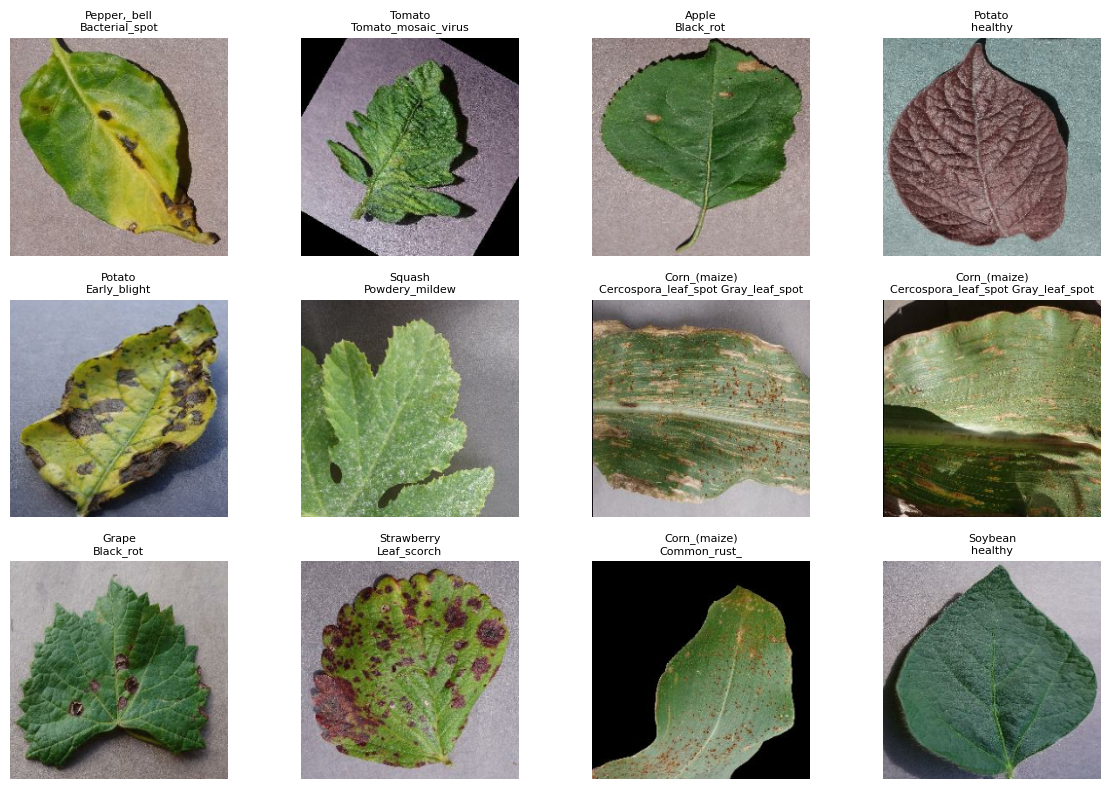

In [5]:
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        label_idx = int(np.argmax(labels[i].numpy()))
        plt.title(class_names[label_idx].replace('___', '\n'), fontsize=8)
        plt.axis('off')
plt.tight_layout()

## 4. Shared model helpers

In [6]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.08),
        tf.keras.layers.RandomZoom(0.10),
    ],
    name='data_augmentation',
)


def plot_history(history, title):
    metrics = history.history
    epochs = range(1, len(metrics['loss']) + 1)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, metrics['loss'], label='train')
    plt.plot(epochs, metrics['val_loss'], label='valid')
    plt.title(f'{title} loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, metrics['accuracy'], label='train')
    plt.plot(epochs, metrics['val_accuracy'], label='valid')
    plt.title(f'{title} accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()


def make_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=3,
            restore_best_weights=True,
            mode='max',
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=2,
            min_lr=1e-6,
        ),
    ]

## 5. Custom CNN baseline

This model is intentionally small. It is useful as a baseline, but transfer learning normally performs better on this dataset.

In [7]:
def build_custom_cnn(num_classes):
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)

    for filters in [32, 64, 128]:
        x = tf.keras.layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(192, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.35)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = tf.keras.Model(inputs, outputs, name='custom_cnn_baseline')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
        steps_per_execution=32,
    )
    return model


with strategy.scope():
    custom_cnn = build_custom_cnn(num_classes)
custom_cnn.summary()

Model: "custom_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 192)    │       221,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 192)    │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 192)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 192)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │         7,334 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,206 (1.23 MB)

 Trainable params: 322,374 (1.23 MB)

 Non-trainable params: 832 (3.25 KB)

In [8]:
CUSTOM_CNN_EPOCHS = 8

custom_history = custom_cnn.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=CUSTOM_CNN_EPOCHS,
    callbacks=make_callbacks(),
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


...

1024/1099 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9601 - loss: 0.1407

1056/1099 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9601 - loss: 0.1407

1088/1099 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9601 - loss: 0.1408

1120/1099 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9601 - loss: 0.1408

1099/1099 ━━━━━━━━━━━━━━━━━━━━ 33s 30ms/step - accuracy: 0.9602 - loss: 0.1424 - val_accuracy: 0.8862 - val_loss: 0.3498 - learning_rate: 3.0000e-04


{'loss': 0.22868949174880981, 'compile_metrics': 0.9329615235328674}


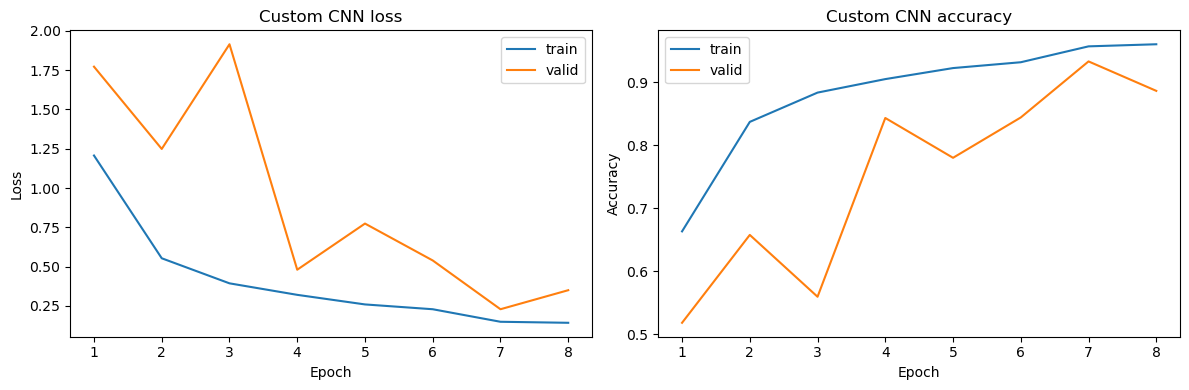

In [9]:
plot_history(custom_history, 'Custom CNN')
custom_eval = custom_cnn.evaluate(valid_ds, verbose=0)
print(dict(zip(custom_cnn.metrics_names, custom_eval)))

## 6. MobileNetV2 transfer-learning model

MobileNetV2 keeps the notebook simple while using strong pretrained visual features. The base is frozen first, then the last layers are optionally fine-tuned with a lower learning rate.

In [10]:
def build_mobilenetv2(num_classes):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights='imagenet',
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = tf.keras.Model(inputs, outputs, name='plant_disease_mobilenetv2')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
        steps_per_execution=32,
    )
    return model, base_model


with strategy.scope():
    mobilenet_model, mobilenet_base = build_mobilenetv2(num_classes)
mobilenet_model.summary()

      0/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  40960/9406464 ━━━━━━━━━━━━━━━━━━━━ 11s 1us/step

  49152/9406464 ━━━━━━━━━━━━━━━━━━━━ 19s 2us/step

  81920/9406464 ━━━━━━━━━━━━━━━━━━━━ 21s 2us/step

 163840/9406464 ━━━━━━━━━━━━━━━━━━━━ 14s 2us/step

...

Model: "plant_disease_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
MOBILENET_EPOCHS = 8

mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=MOBILENET_EPOCHS,
    callbacks=make_callbacks(),
)

Epoch 1/8


  32/1099 ━━━━━━━━━━━━━━━━━━━━ 8:07 457ms/step - accuracy: 0.2285 - loss: 2.9832

  64/1099 ━━━━━━━━━━━━━━━━━━━━ 4:01 234ms/step - accuracy: 0.3190 - loss: 2.6386

  96/1099 ━━━━━━━━━━━━━━━━━━━━ 2:39 159ms/step - accuracy: 0.3838 - loss: 2.3914

 128/1099 ━━━━━━━━━━━━━━━━━━━━ 1:58 122ms/step - accuracy: 0.4319 - loss: 2.2056

...

1024/1099 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9430 - loss: 0.1736

1056/1099 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9429 - loss: 0.1738

1088/1099 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9429 - loss: 0.1740

1120/1099 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9428 - loss: 0.1742

1099/1099 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9417 - loss: 0.1797 - val_accuracy: 0.9498 - val_loss: 0.1567 - learning_rate: 0.0010


{'loss': 0.15190503001213074, 'compile_metrics': 0.9502617716789246}


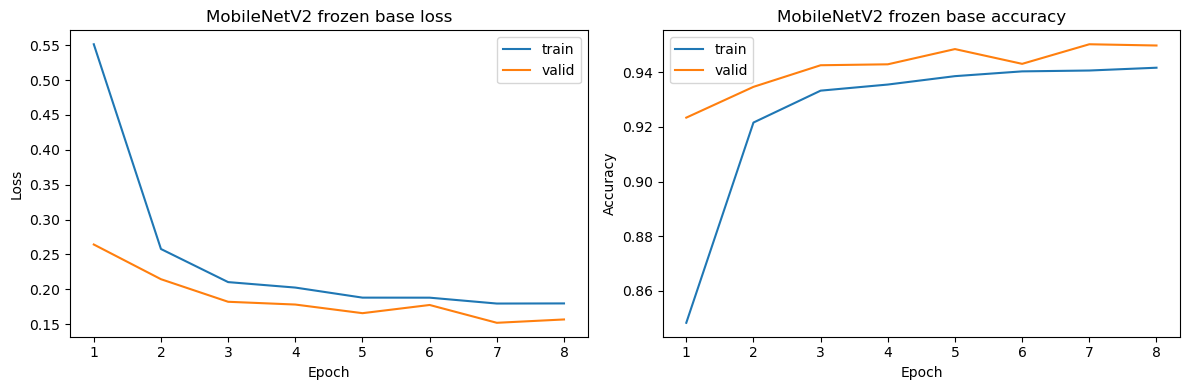

In [12]:
plot_history(mobilenet_history, 'MobileNetV2 frozen base')
mobilenet_eval = mobilenet_model.evaluate(valid_ds, verbose=0)
print(dict(zip(mobilenet_model.metrics_names, mobilenet_eval)))

## 7. Optional fine-tuning

Fine-tuning usually improves validation accuracy after the classifier head has learned. Keep the learning rate small to avoid damaging pretrained weights.

In [13]:
mobilenet_base.trainable = True

# Freeze most layers and tune only the top feature layers.
for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

with strategy.scope():
    mobilenet_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
        steps_per_execution=32,
    )

FINE_TUNE_EPOCHS = 5

fine_tune_history = mobilenet_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=make_callbacks(),
)

Epoch 1/5


  32/1099 ━━━━━━━━━━━━━━━━━━━━ 5:26 306ms/step - accuracy: 0.6792 - loss: 1.4157

  64/1099 ━━━━━━━━━━━━━━━━━━━━ 2:46 161ms/step - accuracy: 0.6909 - loss: 1.3713

  96/1099 ━━━━━━━━━━━━━━━━━━━━ 1:53 113ms/step - accuracy: 0.7020 - loss: 1.3126

 128/1099 ━━━━━━━━━━━━━━━━━━━━ 1:25 89ms/step - accuracy: 0.7126 - loss: 1.2582 

...

1024/1099 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9669 - loss: 0.1087

1056/1099 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9669 - loss: 0.1086

1088/1099 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9669 - loss: 0.1085

1120/1099 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9669 - loss: 0.1085

1099/1099 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step - accuracy: 0.9674 - loss: 0.1059 - val_accuracy: 0.9651 - val_loss: 0.1050 - learning_rate: 1.0000e-05


{'loss': 0.10624971240758896, 'compile_metrics': 0.9653425812721252}


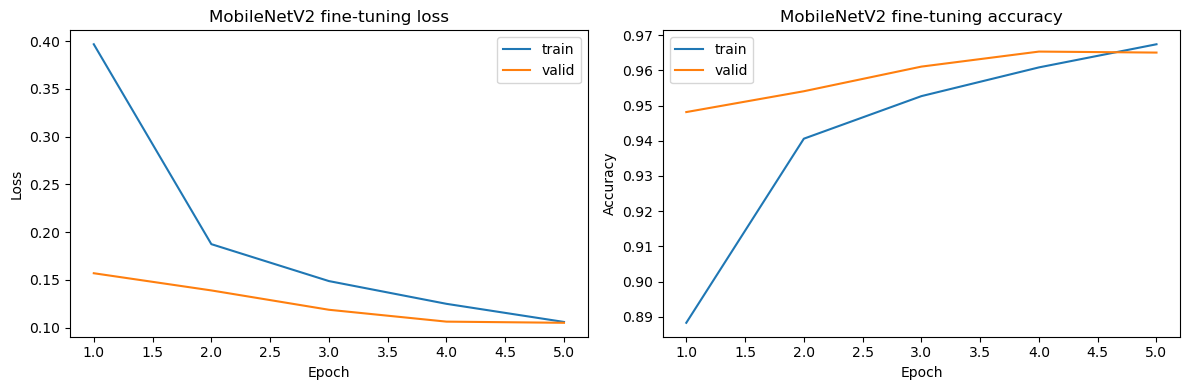

In [14]:
plot_history(fine_tune_history, 'MobileNetV2 fine-tuning')
fine_tuned_eval = mobilenet_model.evaluate(valid_ds, verbose=0)
print(dict(zip(mobilenet_model.metrics_names, fine_tuned_eval)))

## 8. Validation report

In [15]:
y_true = []
y_pred = []

for images, labels in valid_ds:
    probabilities = mobilenet_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(probabilities, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9727    0.9881    0.9803       504
                                 Apple___Black_rot     0.9861    0.9960    0.9910       497
                          Apple___Cedar_apple_rust     0.9954    0.9841    0.9897       440
                                   Apple___healthy     0.9880    0.9801    0.9840       502
                               Blueberry___healthy     0.9956    0.9956    0.9956       454
          Cherry_(including_sour)___Powdery_mildew     1.0000    0.9786    0.9892       421
                 Cherry_(including_sour)___healthy     0.9913    0.9956    0.9934       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9197    0.9220    0.9208       410
                       Corn_(maize)___Common_rust_     0.9937    0.9979    0.9958       477
               Corn_(maize)___Northern_Leaf_Blight     0.9284    0.9245    0.92

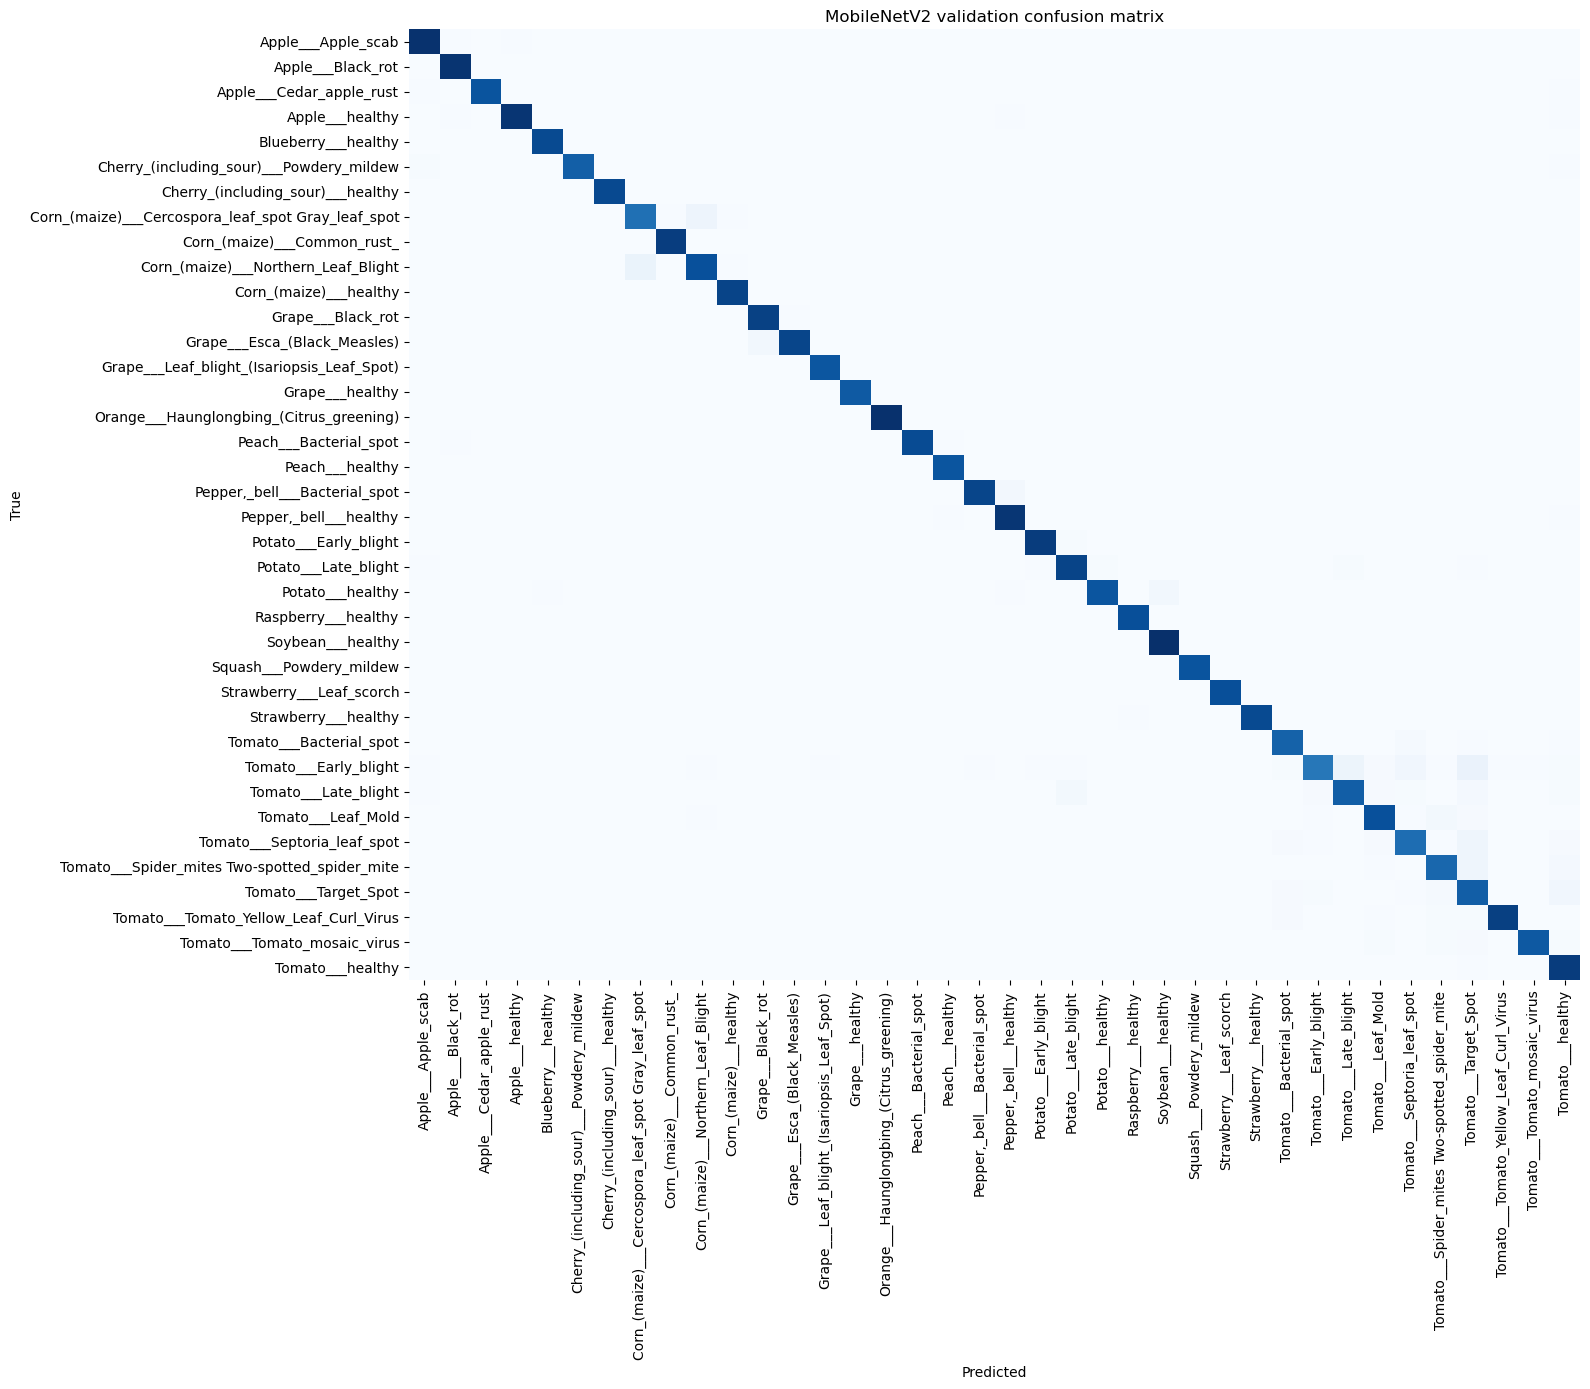

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
if sns is not None:
    sns.heatmap(cm, cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar=False)
else:
    plt.imshow(cm, cmap='Blues')
    plt.colorbar()
    plt.xticks(range(num_classes), class_names, rotation=90, fontsize=7)
    plt.yticks(range(num_classes), class_names, fontsize=7)

plt.title('MobileNetV2 validation confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()

## 9. Save and reload the final model

In [22]:
custom_cnn.save(CUSTOM_MODEL_PATH)
mobilenet_model.save(MOBILENET_MODEL_PATH)

with open(NOTEBOOK_DIR / 'plant_disease_class_names.json', 'w') as f:
    json.dump(class_names, f, indent=2)

reloaded_custom_model = tf.keras.models.load_model(CUSTOM_MODEL_PATH)
reloaded_mobilenet_model = tf.keras.models.load_model(MOBILENET_MODEL_PATH)

print(f'Saved custom CNN to {CUSTOM_MODEL_PATH}')
print('Reloaded custom CNN output shape:', reloaded_custom_model.output_shape)
print(f'Saved MobileNetV2 to {MOBILENET_MODEL_PATH}')
print('Reloaded MobileNetV2 output shape:', reloaded_mobilenet_model.output_shape)


NameError: name 'CUSTOM_MODEL_PATH' is not defined

## 10. Predict standalone test images

In [21]:
def load_image_for_prediction(image_path):
    image = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    array = tf.keras.utils.img_to_array(image)
    return np.expand_dims(array, axis=0)


def predict_image(model, image_path, class_names, top_k=3):
    batch = load_image_for_prediction(image_path)
    probabilities = model.predict(batch, verbose=0)[0]
    top_indices = np.argsort(probabilities)[-top_k:][::-1]
    return [
        {
            'class': class_names[int(idx)],
            'confidence': float(probabilities[int(idx)]),
        }
        for idx in top_indices
    ]


def print_predictions(model_name, predictions):
    print(f'  {model_name}')
    for item in predictions:
        print(f"    {item['class']}: {item['confidence']:.2%}")


test_images = sorted(TEST_DIR.glob('*.JPG')) + sorted(TEST_DIR.glob('*.jpg')) + sorted(TEST_DIR.glob('*.png'))
print(f'Test images found: {len(test_images)}')

for image_path in test_images[:10]:
    custom_predictions = predict_image(reloaded_custom_model, image_path, class_names, top_k=3)
    mobilenet_predictions = predict_image(reloaded_mobilenet_model, image_path, class_names, top_k=3)

    print('', image_path.name)
    print_predictions('Custom CNN', custom_predictions)
    print_predictions('MobileNetV2', mobilenet_predictions)


Test images found: 33


NameError: name 'reloaded_custom_model' is not defined

In [ ]:
rows = min(6, len(test_images))
plt.figure(figsize=(14, 3 * rows))

for i, image_path in enumerate(test_images[:rows]):
    custom_top = predict_image(reloaded_custom_model, image_path, class_names, top_k=1)[0]
    mobilenet_top = predict_image(reloaded_mobilenet_model, image_path, class_names, top_k=1)[0]
    image = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)

    ax = plt.subplot(rows, 1, i + 1)
    ax.imshow(image)
    ax.set_title(
        f"{image_path.name}\n"
        f"Custom: {custom_top['class']} ({custom_top['confidence']:.1%}) | "
        f"MobileNetV2: {mobilenet_top['class']} ({mobilenet_top['confidence']:.1%})"
    )
    ax.axis('off')

plt.tight_layout()
